# ***ASSIGNMENT:***
# ***Road Damage Detection using YOLO11***

In [72]:

!pip install ultralytics

# ***Dataset Preparation***

Import Roboflow and Connect API

Download Dataset

Check Dataset Folders

Check Dataset Image Counts

Check Dataset Classes

Visualize Sample Images

Check Image Annotations and Labels


In [73]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="uLieoVgq0XsCqeqqL8wD")
project = rf.workspace("baka-1ravj").project("road-damage-det")
version = project.version(4)
dataset = version.download("yolov11")

loading Roboflow workspace...
loading Roboflow project...


In [74]:
import os

print(os.listdir(dataset.location))

['README.dataset.txt', 'README.roboflow.txt', 'data.yaml', 'test', 'train', 'valid']


In [75]:
import yaml

with open(dataset.location + "/data.yaml", "r") as f:
    data = yaml.safe_load(f)

print("Classes:", data["names"])
print("Total classes:", data["nc"])

Classes: ['alligator cracking', 'edge cracking', 'longitudinal cracking', 'patching', 'rutting', 'transverse cracking']
Total classes: 6


In [76]:
import os

for folder in ["train", "valid", "test"]:
    path = os.path.join(dataset.location, folder, "images")
    print(folder, "images:", len(os.listdir(path)))

train images: 8214
valid images: 783
test images: 391


In [77]:
data["train"] = dataset.location + "/train/images"
data["val"] = dataset.location + "/valid/images"
data["test"] = dataset.location + "/test/images"

with open(dataset.location + "/data.yaml", "w") as f:
    yaml.safe_dump(data, f, sort_keys=False)

print("Dataset paths updated!")

Dataset paths updated!


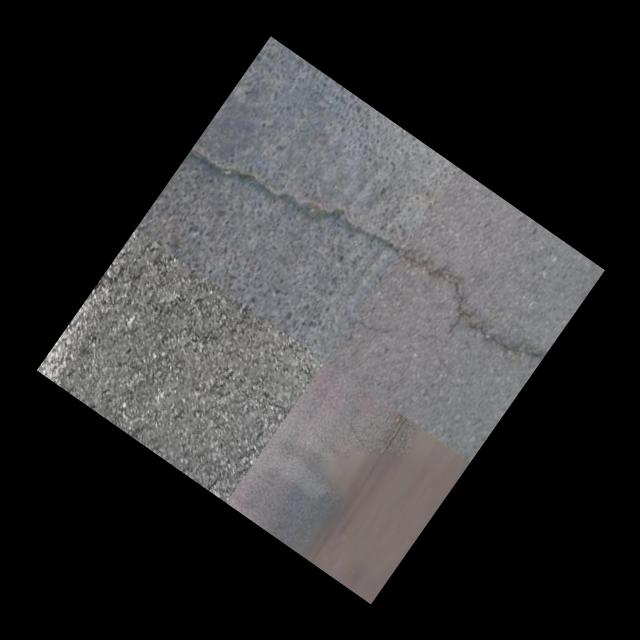

In [78]:
from PIL import Image    #Visualize Sample Images
from IPython.display import display
import os

img_path = dataset.location + "/train/images/" + os.listdir(dataset.location + "/train/images")[0]
display(Image.open(img_path))

In [79]:
import os #Check Image Annotations and Labels

label_path = dataset.location + "/train/labels/" + os.listdir(dataset.location + "/train/labels")[0]
print(open(label_path).read().splitlines()[0])

2 0.253125 0.6046875 0.1171875 0.1890625


In [80]:
from ultralytics import YOLO

model = YOLO("yolo11n.pt")

print("YOLO11 model loaded successfully!")

YOLO11 model loaded successfully!


# **Model Training**

Load Pretrained YOLO11n Model

Train the Model

Monitor Training Progress

In [ ]:
results = model.train(
    data=dataset.location + "/data.yaml",
    epochs=10,
    imgsz=640,
    batch=8
)

Ultralytics 8.4.174 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/road-damage-dét-4/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-6, nbs=64, nms=None, opset=None, optimize=False,

In [ ]:
from IPython.display import display, Image

display(Image(filename="/content/runs/detect/train-2/results.png"))

In [ ]:
from ultralytics import YOLO

best_model = YOLO("/content/runs/detect/train-2/weights/best.pt")

metrics = best_model.val(
    data=dataset.location + "/data.yaml",
    split="test"
)

In [ ]:
from google.colab import files

files.download("/content/runs/detect/train-2/weights/best.pt")

In [ ]:
from ultralytics import YOLO

model = YOLO("/content/runs/detect/train-2/weights/best.pt")

metrics = model.val(
    data=dataset.location + "/data.yaml",
    split="val"
)

In [ ]:
import pandas as pd

df = pd.read_csv(
    "/content/runs/detect/train-2/results.csv"
)

print(df.tail(5).to_string(index=False))

In [ ]:
from ultralytics import YOLO

model = YOLO("/content/runs/detect/train/weights/best.pt")

print("Road Crack Detection model loaded successfully!")

In [ ]:
from ultralytics import YOLO

model1 = YOLO("/content/runs/detect/train-2/weights/best.pt")

res1=model.predict("/content/road-damage-dét-4/test/images/32_jpg.rf.90bf6d696934891c9b6fbc8f1abd9d10.jpg", save=True)

In [ ]:
res1[0].show()

In [ ]:
from ultralytics import YOLO

model1 = YOLO("/content/runs/detect/train-2/weights/best.pt")

res2=model.predict("/content/road-damage-dét-4/test/images/CFD_056_jpg.rf.4298e2e019e7a97289ce7eb0d0b2ffc0.jpg", save=True)

In [ ]:
res2[0].show()

In [ ]:
metrics = model1.val(
    data="/content/road-damage-dét-4/data.yaml",
    split="test"
)

print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)
print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)

In [ ]:
from google.colab import files

uploaded = files.upload()

In [ ]:
image_path = next(iter(uploaded))

res = model1.predict(image_path, save=True)

res[0].show()

In [ ]:
res = model1.predict(
    image_path,
    conf=0.10,
    save=True
)

res[0].show()

Dataset: Road damage images aur labels load kiye.

Training: YOLO model ko 10 epochs train kiya.

Graphs: results.png aur confusion_matrix.png banayi.

Evaluation: Precision, Recall aur mAP check kiya.

Testing: Test images par road damage detect kiya.

Prediction: Image par bounding boxes aur damage classes show ki.

Model: best.pt trained model hai.

Precision: 62.5%

Recall: 56.9%

mAP50: 58.8%

mAP50-95: 38.8%